# 🧠 02 · STDP — 타이밍으로 스스로 배우는 시냅스 (비지도 2인자 학습)

## 1편에서 여기까지 — 그리고 남은 질문
1편에서 우리는 LIF 뉴런을 만들고, 실수 데이터를 스파이크로 인코딩했습니다. 뉴런이 받는 입력 전류는

$$ I[t] = \sum_i S_i[t]\, w_i $$

처럼 **앞쪽 뉴런의 스파이크 $S_i$ 에 연결 세기(가중치) $w_i$ 를 곱해 더한 값**이었습니다. 그런데 그때 $w_i$ 는 우리가 손으로 정한 값이었습니다. 진짜 질문은 여기서 시작합니다: **이 가중치를 데이터로부터 스스로 정할 수는 없을까?** 그것도 정답 라벨 없이, 각 시냅스가 자기 주변 정보만 보고서.

이 편의 답이 **STDP(Spike-Timing-Dependent Plasticity, 스파이크-타이밍-의존 가소성)** 입니다. 이름 그대로 *두 뉴런이 스파이크를 낸 타이밍*만으로 그 사이 가중치를 바꾸는 규칙입니다. 라벨도, 전역 오차도 필요 없이(비지도·지역적) 1편에서 만든 스파이크 뉴런에 가장 자연스럽게 얹히는 첫 학습 규칙입니다.

다시 말하자면 1편에서는 $w$는 고정해놓고, 정보를 인코딩하는데 스파이크 타이밍을 사용했다면, 2편에서는 뉴런들이 터진 시간차를 보고 $w$를 바꾸는 학습을 해 볼 것입니다.

## 이번 편의 파이프라인
- **① 규칙**: 두 스파이크의 시간차 $\Delta t$ 하나로 가중치 변화 $\Delta w$ 를 정하는 STDP '학습 창(window)'을 세운다.
- **② 온라인 구현**: $\Delta t$ 를 일일이 재는 대신, 각 뉴런에 붙인 **흔적(trace)** 의 곱으로 같은 규칙을 지역·실시간으로 돌린다.
- **③ 응용**: 여러 뉴런을 **경쟁(WTA)** 시키고 가중치를 **정규화**하면, 라벨 없이도 각 뉴런이 한 패턴의 **수용장(receptive field)** 검출기로 스스로 특화된다.

## 이번 편 학습 목표
1. **STDP 규칙**: pre→post 순서면 강화(LTP), post→pre 순서면 약화(LTD). 시간차 $\Delta t$ 와 시간상수 $\tau$ 의 함수로 이해한다.
2. **흔적 기반 STDP**: 흔적의 지수 감쇠가 $\Delta t$ 정보를 대신 담아 STDP를 지역·온라인 규칙으로 만드는 과정을 손으로 검증한다.
3. **경쟁적 STDP + 정규화**로 수용장을 비지도 학습한다 — STDP 하나로 특징 검출기가 스스로 생겨남을 확인한다.

In [1]:
# --- 환경 구성: 라이브러리 불러오기 & 재현성/그림 설정 (1편과 동일) ---
import torch
import snntorch as snn
from snntorch import spikegen
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)   # 같은 결과 재현
plt.rcParams["font.family"] = "AppleGothic"   # 한글 폰트 (macOS)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")
print("torch:", torch.__version__, "| snntorch:", snn.__version__)

torch: 2.12.1 | snntorch: 1.0.0


## 1. 배경: 시냅스는 어떻게 "배우는가"

신경망에서 학습이란 결국 **연결의 세기(가중치 $w$)를 바꾸는 일**입니다. 두 뉴런을 잇는 연결 지점을 **시냅스(synapse)** 라 하고, 그 연결이 경험에 따라 세지거나 약해지는 성질을 **시냅스 가소성(synaptic plasticity)** 이라고 합니다. 학습 규칙이란 결국 "어떤 조건에서 $w$ 를 얼마나 바꿀지"를 정하는 식입니다.

**헵의 원리(Hebb, 1949)** 는 그 가장 오래된 답입니다.

> "한 뉴런이 다른 뉴런의 발화에 반복적으로 기여하면, 그 둘을 잇는 연결이 강해진다."

흔히 *"Cells that fire together, wire together"* 로 요약됩니다. 앞 뉴런(**pre**, presynaptic, 신호를 *보내는* 쪽)과 뒤 뉴런(**post**, postsynaptic, 신호를 *받는* 쪽)이 **함께 활동**하면 연결을 강화하라는 것입니다. 두 이름은 시냅스를 기준으로 앞/뒤에 있다는 뜻이라 앞으로 계속 씁니다.

STDP는 이 "함께"를 **시간 순서**로 날카롭게 다듬은 규칙입니다. 그냥 동시에 켜졌는지가 아니라 **누가 먼저 켜졌는지**를 봅니다. 연결이 세지는 것을 **LTP(long-term potentiation, 장기 강화)**, 약해지는 것을 **LTD(long-term depression, 장기 약화)** 라 부릅니다 — 실제 뇌 시냅스에서 관측되는 현상이고, 이 발화 순서 의존성은 Bi & Poo(1997–1998) 등의 실험으로 정량화됐습니다.

### 왜 "2인자(two-factor)"라고 부르는가
STDP에서 가중치 변화는 **두 신호의 곱**으로 정해집니다: **① pre 뉴런의 활동 × ② post 뉴런의 활동.** 이 둘이 곧 두 인자(factor)입니다. "지금 실제로 바꿀지"를 결정하는 **세 번째 인자(보상·신경조절 신호)** 는 다음 편(3인자 학습)에서 배울 것이고, 이번 편은 타이밍이라는 두 인자만으로 어디까지 배울 수 있는지를 봅니다.

## 2. STDP 규칙: 시간차 $\Delta t$ 의 함수

pre와 post가 각각 한 번 스파이크를 냈다고 하고, 그 시간차를

$$ \Delta t = t_{post} - t_{pre} $$

로 정의합니다. STDP는 이 $\Delta t$ 하나로 가중치 변화 $\Delta w$ 를 정합니다:

$$ \Delta w = \begin{cases} +A_+ \, e^{-\Delta t/\tau_+} & \Delta t > 0 \quad(\text{pre가 먼저} \to \text{LTP, 강화}) \\[4pt] -A_- \, e^{+\Delta t/\tau_-} & \Delta t < 0 \quad(\text{post가 먼저} \to \text{LTD, 약화}) \end{cases} $$

### 기호
- $\Delta t = t_{post}-t_{pre}$ : 두 스파이크의 **시간차**(스텝 단위). 부호가 핵심입니다 — 양수면 pre가 먼저, 음수면 post가 먼저.
- $A_+,\ A_-$ : 강화·약화의 **최대 크기**($\Delta t\to 0$ 일 때 값). 첨자 $+$는 강화(potentiation), $-$는 약화(depression)를 가리키며 보통 $A_+ \approx A_-$ 로 둡니다.
- $\tau_+,\ \tau_-$ : **시간상수(time constant)**. 지수 감쇠의 빠르기를 정합니다. 기호 $\tau$(타우)는 물리·공학에서 RC 회로 같은 지수 감쇠의 시간상수에 쓰는 표준 기호를 그대로 가져온 것입니다.

### $\tau$ 를 숫자로 읽기
$\tau$ 는 **"영향이 얼마나 넓은 시간차까지 미치나"** 를 정하는 창(window)의 폭입니다. 지수 $e^{-\Delta t/\tau}$ 에 $\Delta t=\tau$ 를 넣으면 $e^{-1}\approx 0.37$ — 즉 **시간차가 $\tau$ 만큼 벌어지면 효과가 최고값의 약 37%로 줄어듭니다.** $\Delta t=2\tau$ 면 $e^{-2}\approx 0.14$, $3\tau$ 면 $\approx 0.05$ 로 거의 사라집니다. 그래서

- $\tau$ 가 **크면** 창이 넓어져, 시간상 멀리 떨어져 발화한 쌍도 서로 영향을 줍니다.
- $\tau$ 가 **작으면** 거의 동시에 터진 쌍만 의미가 있습니다.

실제 시냅스에서 이 창의 폭은 대략 $\tau\approx 20\,\text{ms}$ 로 측정됩니다(Bi & Poo, 1998). 우리 시뮬레이션의 시간 단위는 '스텝'이므로, 아래 코드에서는 $\tau_+=\tau_-=20\,\text{스텝}$ 으로 두어 20스텝 남짓의 창을 만듭니다.

### 직관: 순서가 곧 인과
pre가 post의 발화를 **도왔다**면(먼저 터져 post의 막전위를 임계값 쪽으로 밀었다면) 그 연결을 강화하고($\Delta t>0$, LTP), post가 이미 터진 **뒤에야** pre가 터졌다면 이번 발화와는 인과적으로 무관하니 약화합니다($\Delta t<0$, LTD). STDP는 스파이크 **순서로 인과성(causality)** 을 새기는 규칙입니다.

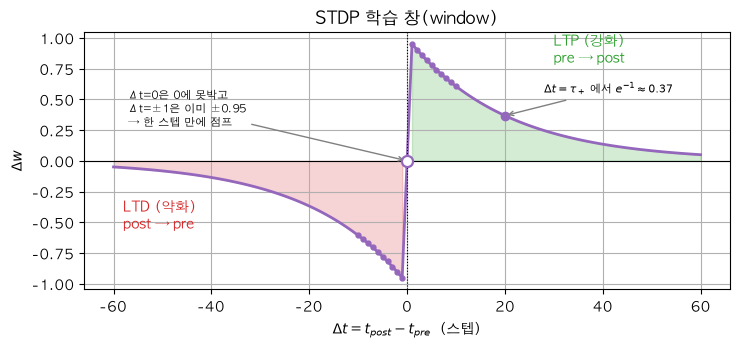

In [5]:
A_plus, A_minus = 1.0, 1.0         # LTP/LTD 최대 크기 A₊, A₋ (Δt→0일 때)
tau_plus, tau_minus = 20.0, 20.0   # 시간상수 τ₊, τ₋ (스텝): 창의 폭
dt = np.arange(-60, 61)            # 시간차 Δt = t_post - t_pre 를 촘촘히 훑음
dw = np.where(dt > 0, A_plus*np.exp(-dt/tau_plus), -A_minus*np.exp(dt/tau_minus))
dw[dt == 0] = 0                    # 정확히 동시(Δt=0)면 순서가 없어 변화 0

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(dt, dw, color="tab:purple", lw=2)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8, ls=":")
ax.fill_between(dt, dw, where=(dt>0), color="tab:green", alpha=0.2)
ax.fill_between(dt, dw, where=(dt<0), color="tab:red", alpha=0.2)

# 실제 값은 정수 Δt에서만 정의되는 이산 표본 — 중앙부(±10)를 점으로 찍어 이산성을 드러낸다
core = np.abs(dt) <= 10
ax.plot(dt[core], dw[core], "o", color="tab:purple", ms=3.5, zorder=5)
ax.plot([0], [0], "o", mfc="white", mec="tab:purple", mew=1.6, ms=8, zorder=6)   # Δt=0은 0에 못박음
ax.annotate("Δt=0은 0에 못박고\nΔt=±1은 이미 ±0.95\n→ 한 스텝 만에 점프",
            xy=(0.0, 0.0), xytext=(-57, 0.42),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, va="center")

# τ 지점 표시: Δt=τ₊ 에서 효과가 e^-1≈0.37 로 감쇠
ax.plot([tau_plus], [A_plus*np.exp(-1)], "o", color="tab:purple")
ax.annotate(r"$\Delta t=\tau_+$ 에서 $e^{-1}\approx 0.37$",
            xy=(tau_plus, A_plus*np.exp(-1)), xytext=(28, 0.55),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8)
ax.text(30, 0.80, "LTP (강화)\npre → post", color="tab:green")
ax.text(-58, -0.55, "LTD (약화)\npost → pre", color="tab:red")
ax.set_xlabel(r"$\Delta t = t_{post} - t_{pre}$  (스텝)"); ax.set_ylabel(r"$\Delta w$")
ax.set_title("STDP 학습 창(window)")
plt.tight_layout(); plt.show()

### 🔎 그림 읽기
- **왜 곡선이 지수로 떨어지나요?** 식 $\Delta w = \pm A e^{-|\Delta t|/\tau}$ 자체가 지수 감쇠라서입니다. 꼭짓점($\Delta t=\pm1$)에서 가장 크고, 시간차가 벌어질수록 급히 0으로 다가갑니다. 오른쪽에 표시된 점이 $\Delta t=\tau_+$(=20스텝) 지점으로, 여기서 이미 최고값의 37%까지 내려왔습니다.
- **가운데가 왜 이렇게 뾰족한가요?** $\Delta t=0$ 에서는 발화 순서가 없어 $\Delta w$ 를 **0으로 못박았는데**(가운데 흰 점), 바로 옆 $\Delta t=\pm1$ 에서는 $\tau=20$ 이 1스텝보다 훨씬 커서 지수가 이미 최댓값의 95%($e^{-1/20}=0.95$)입니다. 그래서 **0 → 0.95로 한 스텝 만에 튀어올랐다가**(거의 수직) $\Delta t=\pm1$ 꼭짓점에서 완만한 감쇠로 꺾입니다(이후 스텝당 −0.05 정도). 이 뾰족함은 규칙의 성질이라기보다 **정수 스텝만 찍어 직선으로 이은 표본화 효과**이며, 진짜 불연속은 $\Delta t=0$ 한 점뿐입니다.
- **왜 오른쪽은 위(+), 왼쪽은 아래(−)로 갈리나요?** 부호가 순서를 나타냅니다. 오른쪽($\Delta t>0$)은 pre가 먼저 → 강화(초록), 왼쪽($\Delta t<0$)은 post가 먼저 → 약화(빨강). 부호가 뒤집히는 이 모양 때문에 STDP 창을 "비대칭 창"이라 부릅니다.
- **점인가요, 선인가요?** 실제 규칙은 정수 $\Delta t$ 에서만 정의되는 **이산 표본**이라, 가운데(±10 안쪽)를 점으로도 찍어 두었습니다. 바깥쪽은 점이 촘촘해 선으로만 그렸을 뿐이고, 실제 학습에서 스파이크 한 쌍은 이 곡선 위의 **점 하나**($\Delta t$ 에 해당하는 높이)로 읽으면 됩니다.

### 🔎 헷갈리는 점: post가 pre보다 "먼저" 발화한다니?
LTD 쪽($\Delta t<0$)을 보면 이상합니다. pre가 신호를 보내야 post가 반응할 텐데, 어떻게 post가 pre보다 먼저 터질 수 있을까요?

핵심은 **post 뉴런 하나에 pre 뉴런이 여럿 붙어 있다**는 점입니다. post는 자기에게 들어오는 **모든** pre의 (스파이크 × 가중치)를 합쳐 막전위를 쌓고, 그 합이 임계값을 넘으면 발화합니다. 그러니 post의 발화는 *특정* 한 pre가 아니라 **그 순간 마침 힘을 보탠 입력들**이 함께 일으킨 사건입니다. 그리고 STDP는 그 한 번의 발화 시각을 기준으로 **모든 시냅스를 각자** 평가합니다.

예를 들어 post 뉴런 O에 세 입력 A, B, C가 붙어 있다고 합시다.

| 시각 $t$ | 사건 | O 입장에서 |
|:--:|:--|:--|
| 5 | A 발화 | 막전위 쌓임 |
| 6 | B 발화 | 막전위 더 쌓여 임계값 도달 |
| 7 | **O 발화** | A·B 덕분에 발화 |
| 9 | C 발화 | 이미 늦음 |

O의 발화 시각은 $t_{post}=7$ 하나뿐입니다. 이제 시냅스별로 $\Delta t = t_{post}-t_{pre}$ 를 따로 계산합니다.

- **A→O**: $7-5=+2>0$ → pre가 먼저 → **LTP**. (A가 발화를 도왔음)
- **B→O**: $7-6=+1>0$ → **LTP**.
- **C→O**: $7-9=-2<0$ → post가 먼저 → **LTD**. (C는 발화 뒤에 왔으니 이번 발화와 무관)

즉 "post가 먼저"란 언제나 **그 특정 시냅스의 pre를 기준으로** 한 말입니다. O는 한 번 터졌을 뿐이고, 그 시각보다 **앞선 입력은 강화**, **뒤진 입력은 약화**됩니다. 이 과정을 여러 번 반복하면 post 뉴런은 자기 발화를 **꾸준히 앞서서 예측하는 입력들**에 점점 더 예민해집니다 — 이것이 4절에서 뉴런이 특정 패턴의 검출기로 특화되는 바로 그 메커니즘입니다.

## 3. 흔적(trace) 기반 STDP — 지역·온라인 구현

2절의 창은 모든 pre-post 쌍의 $\Delta t$ 를 알아야 계산할 수 있습니다. 스파이크마다 상대의 발화 시각을 일일이 기억했다 빼는 건 비효율적이고, "자기 주변만 본다"는 성질이 추가로 구현될 필요가 있습니다. 이제 각 뉴런에 "이 뉴런이 **최근에** 얼마나 발화했나"를 한 숫자로 요약한 기억인 **지수 감쇠 흔적(trace)** 을 하나씩 붙여서 2절에서 배운 STDP의 규칙을 **실시간**으로 구현하는 STDP를 만들어 봅시다.

### 흔적이란? — 뉴런 하나로 먼저
먼저 뉴런 하나만 봅니다. 그 뉴런의 스파이크 열을 $S[t]\in\{0,1\}$ 라 할 때, 흔적 $x[t]$ 는 매 스텝 이렇게 갱신됩니다.

$$ x[t] = \underbrace{\lambda\, x[t-1]}_{\text{① 이전 흔적을 조금 흘려보내고}} + \underbrace{S[t]}_{\text{② 발화했으면 +1}} $$

- **② $S[t]$**: 이번 스텝에 발화했으면($S[t]=1$) 흔적에 1을 더합니다 — "방금 터졌다"는 표시.
- **① $\lambda\, x[t-1]$**: 직전 흔적에 $\lambda$(0~1 사이 상수)를 곱해 조금 줄입니다. 발화가 없으면 흔적은 매 스텝 $\lambda$ 배로 잦아듭니다.

그래서 흔적은 **방금 터졌으면 크고, 한동안 잠잠하면 0으로 사그라듭니다.** 예를 들어 $\lambda=0.8$ 인 뉴런이 $t=0$ 에 한 번 발화하면 흔적은
$$ 1 \;\to\; 0.8 \;\to\; 0.64 \;\to\; 0.512 \;\to\; \cdots \quad(\text{스텝마다} \times 0.8) $$
로 줄고, 만약 $t=3$ 에 또 발화하면 그 위에 1이 얹혀 $0.512+1=1.512$ 가 됩니다. 즉 흔적은 최근 발화들의 **잦아드는 잔향을 겹쳐 쌓은 값**입니다.

### 시냅스 양끝에 하나씩: pre 흔적과 post 흔적
STDP는 **입력 뉴런과 출력 뉴런이 언제 터졌는지의 관계**를 봐야 합니다.  — 똑같은 공식을, 한쪽은 입력(pre) 스파이크에, 다른 쪽은 출력(post) 스파이크에 적용할 뿐입니다.

- **pre 흔적** $\;x_i[t] = \lambda_+\, x_i[t-1] + S^{pre}_i[t]\;$ — **입력 $i$** 가 최근 얼마나 터졌나. (입력은 여럿이라 번호 $i$ 가 붙습니다.)
- **post 흔적** $\;y[t] = \lambda_-\, y[t-1] + S^{post}[t]\;$ — **출력 뉴런**이 최근 얼마나 터졌나. (출력은 하나라 번호가 없습니다.)

여기 $\lambda_+,\lambda_-$ 는 각각 강화·약화 쪽 감쇠 계수로, 2절의 시간상수 $\tau_+,\tau_-$ 에 대응합니다(아래에서 감쇠 계수와 시간상수의 관계에 대해 더 자세히 설명드리겠습니다).

### 흔적으로 쓰는 STDP 규칙
이 두 흔적만 있으면 2절 창을 다음 두 줄로 대신할 수 있습니다.

$$ \text{post가 발화한 순간: } \Delta w_i = +A_+\, x_i \qquad\qquad \text{pre}_i\text{가 발화한 순간: } \Delta w_i = -A_-\, y $$

읽는 법:
- **post가 터질 때** 각 입력의 pre 흔적 $x_i$ 를 봅니다. $x_i$ 에는 "그 입력이 **얼마 전에** 터졌나"가 담겨 있으니, 방금 터진 입력일수록 크게 강화됩니다 — pre가 먼저 → **LTP**.
- **pre가 터질 때** post 흔적 $y$ 를 봅니다. $y$ 가 크면 "post가 방금 터졌다(= 이 pre가 늦었다)"는 뜻이라 약화합니다 — post가 먼저 → **LTD**.

흔적이 지수로 줄어들기 때문에, 여기 곱해지는 $x_i$ 값이 곧 2절 창의 $e^{-\Delta t/\tau_+}$ 와 같아집니다(아래에서 식으로 유도).

### 왜 "지역·온라인"인가
이제 이 규칙의 두 성질에 이름을 붙일 수 있습니다.
- **지역(local)**: 계산에 쓰는 건 그 시냅스 **양끝 두 뉴런이 각자 들고 있는 흔적뿐**입니다. 멀리 있는 다른 뉴런의 상태나 정답 라벨, 전역 오차 같은 건 필요 없습니다.
- **온라인(online)**: 스파이크가 날 때마다 **그 자리에서 즉시** 갱신합니다. 모든 발화 시각을 저장해 두었다가 나중에 $\Delta t$ 를 재는 일이 없습니다 — 흔적이라는 한 숫자가 과거를 대신 기억하니까요.

이 두 성질 덕에 STDP는 각 시냅스가 "자기 앞뒤만" 보면 되는, 실제 뇌의 작동원리와 더 비슷한 규칙이 됩니다.

### $\lambda$(감쇠 계수) ↔ $\tau$(시간상수)
흔적 식에는 2절엔 없던 계수 $\lambda$ 가 새로 등장했습니다. 이건 $\tau$ 와 **다른 것이 아니라, 같은 지수 감쇠를 매 스텝 곱셈으로 쓴 것**뿐입니다. 관계를 한 번 정리하고 갑시다. 스파이크가 한 번 일어난 뒤에 $k$ 스텝이 지나면 흔적은 $\lambda^k$ 로 줄고, 이를 지수꼴로 바꿔 쓰면

$$ \lambda^{k} = e^{k\ln\lambda} = e^{-k/\tau} \quad\Longleftrightarrow\quad \boxed{\;\tau = -\dfrac{1}{\ln\lambda}\;,\qquad \lambda = e^{-1/\tau}\;} $$

| 감쇠 계수 $\lambda$ | 시간상수 $\tau=-1/\ln\lambda$ |
|:--:|:--:|
| 0.80 | ≈ 4.48 스텝 |
| 0.90 | ≈ 9.49 스텝 |
| 0.95 | ≈ 19.50 스텝 |

(그래서 2절의 $\tau=20$ 은 $\lambda=e^{-1/20}\approx 0.951$ 에 해당합니다.) 이 표기 차이는 4절에서 다시 만납니다.

### 흔적이 창을 재현한다 — 식으로 유도, 그리고 $\tau$ 가 곧 '창의 폭'
$\tau$ 는 **"영향이 얼마나 넓은 시간차까지 미치나"** 를 정하는 창(window)의 폭이라고 했었습니다.
이제 "흔적이 곧 창"이라는 말을, **식으로** 확인해 봅니다. pre가 $t=0$ 에 딱 한 번 발화하고 이후로는 잠잠하다고 합시다.

**① 흔적을 풀어 쓰기.** 발화 직후 $x[0]=1$ 이고, 그 뒤엔 입력이 없으니($S^{pre}=0$) 갱신식은 $x[t]=\lambda_+\,x[t-1]$ — 매 스텝 그냥 $\lambda_+$ 배입니다. 그러니 $\Delta t$ 스텝 지나면
$$ x[\Delta t] = \underbrace{\lambda_+\cdot\lambda_+\cdots\lambda_+}_{\Delta t\text{번 곱함}} = \lambda_+^{\,\Delta t}. $$

**② post가 발화하는 순간의 강화량.** 그때 규칙 $\Delta w = +A_+\,x_i$ 에 이 값을 넣으면
$$ \Delta w = A_+\, x[\Delta t] = A_+\,\lambda_+^{\,\Delta t}. $$

**③ $\lambda$ 를 $\tau$ 로 바꾸면 2절 창 그 자체.** 위에서 못박은 $\lambda_+ = e^{-1/\tau_+}$ 를 대입하면
$$ \Delta w = A_+\,\big(e^{-1/\tau_+}\big)^{\Delta t} = A_+\, e^{-\Delta t/\tau_+}. $$
이게 바로 2절 창의 LTP 가지 $+A_+\,e^{-\Delta t/\tau_+}$ 와 **글자 그대로 같은 식**입니다. (LTD 쪽도 post 흔적 $y$ 로 똑같이 유도됩니다.)

**무슨 뜻인가.** 흔적을 매 스텝 갱신하다가 **post가 터지는 그 한 순간에 값을 한 번 읽으면**, 그 값이 이미 $e^{-\Delta t/\tau_+}$ 입니다. $\Delta t$ 를 따로 재지 않아도, **흔적이 얼마나 사그라들었는지 그 크기 자체에 "얼마나 지났나"가 들어 있는** 셈이라 온라인으로 2절 창이 그대로 재현됩니다.

**그리고 이게 곧 '창의 폭'입니다.** 흔적이 사그라드는 시간 규모가 바로 $\tau$ 입니다. pre가 터진 뒤 $\tau$ 스텝쯤 지나면 흔적은 $1/e\approx0.37$ 로, 그만큼 강화도 줄어듭니다. 그래서 2절에서 말한 **"영향이 얼마나 넓은 $\Delta t$ 까지 미치나(창의 폭)"** 가, 온라인 구현에서는 곧 **흔적이 기억을 붙들고 있는 길이**로 나타납니다 — $\lambda$ 가 1에 가까울수록($\tau$ 큼) 흔적이 오래 남아 시간차가 큰 쌍도 강화되고, 작을수록 거의 동시에 터진 쌍만 남습니다.

아래 코드로 이 유도를 **그림으로도** 확인합니다 — 흔적을 그대로 굴린 점들이 지수 창 위에 정확히 얹힙니다.

λ=0.9 → τ = -1/ln(λ) = 9.491 스텝
최대 오차 |흔적 - 창| = 1.1102230246251565e-16


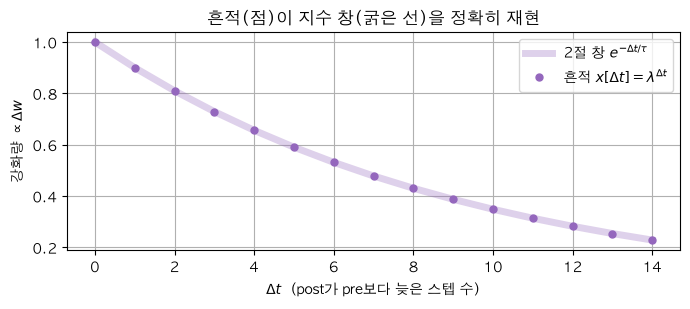

In [6]:
# 흔적 기반 규칙이 2절 창을 재현하는지 수치로 확인
lam = 0.9
tau_equiv = -1.0/np.log(lam)                 # λ -> τ  (= -1/ln λ)
x = 0.0; trace = []
for t in range(15):
    x = lam*x + (1.0 if t == 0 else 0.0)     # pre가 t=0에 한 번 발화한 뒤 감쇠: x[t]=λ x[t-1]
    trace.append(x)
trace = np.array(trace)
window = np.exp(-np.arange(15)/tau_equiv)     # 2절 창의 LTP 가지 e^{-Δt/τ}
print(f"λ={lam} → τ = -1/ln(λ) = {tau_equiv:.3f} 스텝")
print("최대 오차 |흔적 - 창| =", float(np.max(np.abs(trace - window))))   # ≈ 0

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(range(15), window, color="tab:purple", lw=5, alpha=0.30, label=r"2절 창 $e^{-\Delta t/\tau}$")
ax.plot(range(15), trace, "o", color="tab:purple", ms=5, label=r"흔적 $x[\Delta t]=\lambda^{\Delta t}$")
ax.set_xlabel(r"$\Delta t$  (post가 pre보다 늦은 스텝 수)"); ax.set_ylabel(r"강화량 $\propto \Delta w$")
ax.set_title("흔적(점)이 지수 창(굵은 선)을 정확히 재현"); ax.legend()
plt.tight_layout(); plt.show()

## 4. 경쟁적 STDP로 수용장(receptive field) 학습하기

2절에서 STDP가 뭐고, 규칙은 뭔지 배웠고, 3절에서는 그걸 **흔적**을 통해 실시간으로 어떻게 계산하는지 배웠습니다. 이제 STDP 하나로 **비지도 특징 학습**을 해보며 STDP를 어떻게 사용할 수 있는지 알아봅시다. 목표는 "라벨을 안 줘도 뉴런들이 각각 하나의 입력 패턴에 특화되는가?"입니다.

**셋업**
- **입력**: 12×12 이미지에서 나온 세 패턴(세로 막대 / 가로 막대 / 대각선)을 무작위로 하나씩, rate 인코딩(1편의 `spikegen.rate`)으로 스파이크 다발(volley)로 제시. 픽셀 144개 = 입력 뉴런 144개.
- **출력**: LIF 뉴런 6개. 각자 144개 입력에 시냅스($w$)를 가짐.
- **경쟁(WTA, winner-take-all)**: 한 번의 제시에서 **가장 많이 발화한 뉴런(승자)만** 학습. 뇌에서 이웃 뉴런을 서로 억누르는 측면 억제(lateral inhibition)로 승자만 남는 것을 단순화한 것.
- **정규화(normalization / homeostasis)**: 학습 뒤 승자의 가중치 합을 늘 일정($W_{total}$)하게 되돌림.

### 이 코드가 쓰는 STDP는 "강화(LTP) + 정규화"
2절 창에는 강화(LTP)와 약화(LTD)가 둘 다 있었지만, 아래 구현은 **강화 항만** 명시적으로 씁니다: post가 발화한 순간의 pre 흔적을 적립($+A_+ x_i$)해 승자의 가중치를 올립니다. **약화는 정규화가 대신**합니다 — 합을 일정하게 유지하니, 한 시냅스가 강해지면 나머지는 자동으로 밀려 내려갑니다. 이 "밀려남"이 사실상 LTD 역할을 하며, 이런 강화+정규화 조합은 경쟁적 STDP의 표준 설계입니다(예: Diehl & Cook, 2015).

정규화가 핵심입니다. 정규화가 없으면 모든 시냅스가 상한까지 올라 뉴런이 아무 자극에나 반응(선택성 상실)합니다. 정규화가 "제한된 총량을 어디에 쓸까"의 경쟁을 만들어 **각 뉴런이 한 패턴에 특화**되게 합니다.

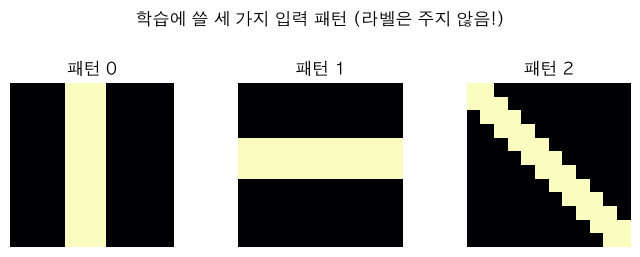

In [4]:
# --- 세 가지 패턴 만들기 (12x12) ---
g = 12
def make_patterns():
    P = []
    v = np.zeros((g, g)); v[:, 4:7] = 1.0; P.append(v)     # 세로 막대
    h = np.zeros((g, g)); h[4:7, :] = 1.0; P.append(h)     # 가로 막대
    d = np.zeros((g, g))
    for i in range(g):
        for j in range(g):
            if abs(i-j) <= 1: d[i, j] = 1.0                # 대각선
    P.append(d)
    return [torch.tensor(p, dtype=torch.float32).flatten() for p in P]

patterns = make_patterns(); K = len(patterns)
fig, ax = plt.subplots(1, K, figsize=(7, 2.4))
for k in range(K):
    ax[k].imshow(patterns[k].reshape(g, g), cmap="magma"); ax[k].set_title(f"패턴 {k}"); ax[k].axis("off")
plt.suptitle("학습에 쓸 세 가지 입력 패턴 (라벨은 주지 않음!)", y=1.05); plt.tight_layout(); plt.show()

### 학습 코드의 변수와 `present()` 함수
아래 학습 루프에 나오는 변수를 먼저 정리합니다. 코드 변수도 하나의 기호이며 본문 개념과 1:1로 이어집니다.

| 변수 | 뜻 | 값 / 유래 |
|---|---|---|
| `n_in`, `n_out` | 입력·출력 뉴런 수 | 144(=12×12), 6 |
| `beta` | LIF 누수 계수 $\beta$ (1편) | 0.9 |
| `thr` | 발화 임계값 $\theta$ | 6.0 — 전류가 최대 144개 시냅스의 합이라 1편의 $\theta{=}1$ 보다 높게 잡음 |
| `lam_pre` | pre 흔적 감쇠 계수 $\lambda_+$ | 0.8 ($\tau\approx 4.5$ 스텝) — 3절의 $\lambda$, **시간상수가 아님** |
| `A` | STDP 강화 크기 $A_+$ (학습률 겸용) | 0.05 |
| `T_win` | 한 번 제시하는 시간창 길이 | 25 스텝 |
| `n_trials` | 총 제시 횟수 | 1500 |
| `W_total` | 각 뉴런 가중치 합의 정규화 목표 | 8.0 |

`present()` 는 **패턴 한 번의 제시**를 시뮬레이션합니다.

```python
counts, ptr = present(pat, w, learn=True)
# 입력:  pat = 길이 144 패턴 벡터,  w = [n_out,144] 가중치,  learn = STDP 강화 적립 여부
# 출력:  counts = [n_out]       각 뉴런이 T_win 동안 낸 스파이크 수 (WTA 승자 판정용)
#        ptr    = [n_out, 144]  각 시냅스의 강화 적립량 Σ_t (S_post · x_pre)  (= LTP 항)
```

즉 패턴을 스파이크로 바꿔 6개 뉴런에 흘리고, 각 뉴런의 발화 수(`counts`)와 STDP 강화 후보량(`ptr`)을 돌려줍니다. 바깥 루프는 `counts` 로 승자를 뽑아 그 뉴런에만 `ptr` 로 가중치를 올린 뒤 정규화합니다.

In [5]:
# --- 경쟁적 STDP 학습 ---
n_in = g*g; n_out = 6
beta, thr = 0.9, 6.0               # LIF 누수 계수 β, 임계값 θ (입력이 최대 144시냅스 합이라 높게)
lam_pre, A = 0.8, 0.05             # pre 흔적 감쇠 계수 λ₊(≈τ 4.5스텝), STDP 강화 크기 A₊
T_win, n_trials = 25, 1500         # 한 제시의 시간창, 총 제시 횟수
W_total = 8.0                      # 각 뉴런 가중치 합의 정규화 목표

w = torch.rand(n_out, n_in)
w = w / w.sum(1, keepdim=True) * W_total   # 시작부터 합을 W_total 로 맞춤
w_init = w.clone()                 # 학습 전 (무작위) 저장
lif = snn.Leaky(beta=beta, threshold=thr, reset_mechanism="zero")

def present(pat, w, learn=True):
    spk_in = spikegen.rate(pat*0.6, num_steps=T_win)     # 패턴 -> rate volley [T_win,144] (ON 픽셀 p=0.6)
    mems = torch.zeros(n_out); xpre = torch.zeros(n_in)  # post 막전위, pre 흔적 x
    counts = torch.zeros(n_out); ptr = torch.zeros(n_out, n_in)
    for t in range(T_win):
        xpre = lam_pre*xpre + spk_in[t]                  # 3절: x[t] = λ₊·x[t-1] + S_pre[t]
        cur = (w * spk_in[t]).sum(1)                     # 입력전류 I = Σ_i S_i·w_i  (뉴런별) [n_out]
        s, mems = lif(cur, mems)                         # (전류,막전위)->(스파이크,막전위)  1편 snn.Leaky
        counts += s
        if learn:
            # post 발화 순간의 pre 흔적 적립 = STDP 강화항 (+A₊·x_i)
            ptr += s.unsqueeze(1) * xpre.unsqueeze(0)
    return counts, ptr

snaps = []
for tr in range(n_trials):
    k = np.random.randint(K)                             # 패턴 무작위 선택 (라벨은 학습에 안 씀)
    counts, ptr = present(patterns[k], w, learn=True)
    winner = int(counts.argmax()) if counts.max() > 0 else np.random.randint(n_out)
    w[winner] += A * ptr[winner]                         # 승자만 강화(LTP)
    w[winner].clamp_(min=0.0)                            # 가중치 음수 방지
    w[winner] = w[winner] / w[winner].sum() * W_total    # 정규화 -> 나머지는 밀려남(=LTD 역할)
    if tr % 300 == 0: snaps.append(w.clone())
print("학습 완료. 각 뉴런 가중치 합(정규화 확인):", [round(float(w[m].sum()),1) for m in range(n_out)])

학습 완료. 각 뉴런 가중치 합(정규화 확인): [8.0, 8.0, 8.0, 8.0, 8.0, 8.0]


### 결과: 무작위였던 시냅스가 패턴 그 자체가 된다
학습 전(무작위) vs 학습 후, 각 뉴런의 144개 가중치를 다시 12×12로 되돌려 그립니다. 아무도 "이게 세로 막대야"라고 알려주지 않았는데, 뉴런들이 **스스로 각 패턴의 검출기(수용장)** 가 됩니다. 수용장이란 "이 뉴런이 가장 세게 반응하는 입력 모양"으로, 여기서는 곧 학습된 가중치 그림 자체입니다.

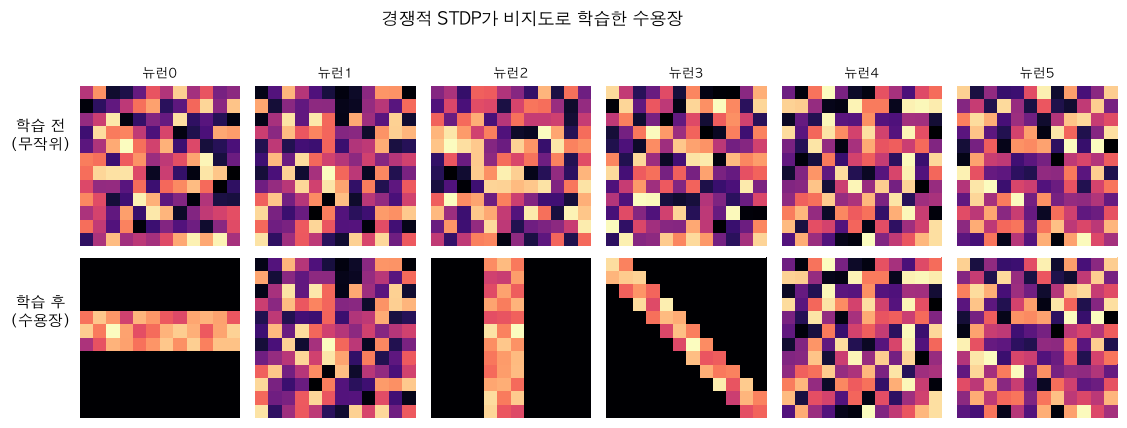

In [6]:
fig, ax = plt.subplots(2, n_out, figsize=(12, 4.2))
for m in range(n_out):
    ax[0, m].imshow(w_init[m].reshape(g, g), cmap="magma"); ax[0, m].axis("off")
    ax[1, m].imshow(w[m].reshape(g, g), cmap="magma");      ax[1, m].axis("off")
    ax[0, m].set_title(f"뉴런{m}", fontsize=9)
ax[0, 0].set_ylabel("학습 전", fontsize=11); ax[1, 0].set_ylabel("학습 후", fontsize=11)
# ylabel이 axis off로 안 보이니 텍스트로
fig.text(0.09, 0.72, "학습 전\n(무작위)", ha="center", va="center", fontsize=11)
fig.text(0.09, 0.30, "학습 후\n(수용장)", ha="center", va="center", fontsize=11)
plt.suptitle("경쟁적 STDP가 비지도로 학습한 수용장", y=1.02)
plt.tight_layout(rect=[0.11,0,1,1]); plt.show()

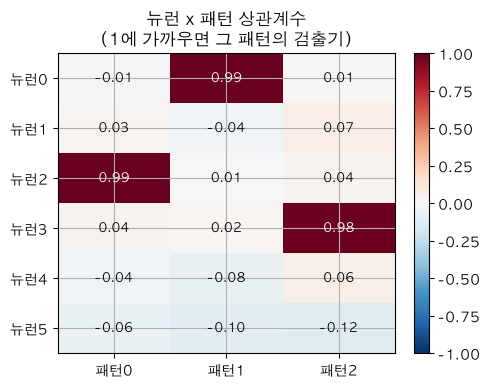

검출기가 생긴 패턴: [0, 1, 2] / [0, 1, 2] -> 3개 패턴 모두 커버!


In [7]:
# 각 뉴런이 어떤 패턴에 특화됐는지: 가중치 vs 패턴 상관계수
def corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float((a @ b) / (a.norm()*b.norm() + 1e-9))

Cmat = np.array([[corr(w[m], patterns[k]) for k in range(K)] for m in range(n_out)])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(Cmat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(K)); ax.set_xticklabels([f"패턴{k}" for k in range(K)])
ax.set_yticks(range(n_out)); ax.set_yticklabels([f"뉴런{m}" for m in range(n_out)])
for m in range(n_out):
    for k in range(K):
        ax.text(k, m, f"{Cmat[m,k]:.2f}", ha="center", va="center",
                color="white" if abs(Cmat[m,k])>0.5 else "black", fontsize=9)
ax.set_title("뉴런 x 패턴 상관계수\n(1에 가까우면 그 패턴의 검출기)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

covered = sorted(set(int(np.argmax(Cmat[m])) for m in range(n_out) if Cmat[m].max() > 0.5))
print("검출기가 생긴 패턴:", covered, "/", list(range(K)),
      "->", "3개 패턴 모두 커버!" if len(covered)==K else "일부만 커버")

### 🔎 그림 읽기
- **위/아래 두 줄(가중치 그림):** 위는 학습 전 무작위, 아래는 학습 후입니다. 아래 줄에서 몇몇 뉴런의 가중치가 세로·가로·대각선 모양으로 또렷해졌다면, 그 뉴런이 그 패턴에 강하게 반응하도록 시냅스가 재배치된 것입니다. 밝을수록 큰 가중치.
- **상관계수 표(뉴런×패턴):** 각 칸은 "그 뉴런의 가중치 그림"과 "그 패턴"의 상관계수입니다. **+1(진한 파랑)에 가까우면 그 패턴의 검출기**라는 뜻이고, 한 뉴런의 행에서 한 칸만 크게 튀면 그 뉴런이 한 패턴에 특화됐다는 신호입니다.
- **뉴런은 6개인데 패턴은 3개, 왜?** 뉴런이 패턴보다 많으므로 같은 패턴을 여러 뉴런이 나눠 검출할 수 있습니다(중복 검출기). 마지막 줄 출력의 "검출기가 생긴 패턴"이 3개를 모두 덮으면, 6개 뉴런이 경쟁을 통해 세 패턴을 빠짐없이 커버한 것입니다.
- **음의 상관(빨강)은?** 그 패턴과 반대 모양(패턴이 어두운 곳에 가중치가 몰린 상태)이라는 뜻입니다. 정규화가 총량을 한정하니, 한 패턴에 특화된 뉴런은 다른 패턴에는 자연히 약하거나 음의 상관을 보입니다.

## 5. 정리 & 다음 편 예고

### 배운 것
- **STDP = 2인자 규칙**: pre×post의 타이밍만으로 $\Delta w$ 결정. $\Delta t = t_{post}-t_{pre}$ 가 양수면 LTP, 음수면 LTD.
- **시간상수 $\tau$** 가 창의 폭을 정하고($\Delta t=\tau$ 에서 37%로 감쇠), 온라인 구현의 **감쇠 계수 $\lambda$** 와 $\tau=-1/\ln\lambda$ 로 대응한다.
- **흔적 기반 구현**으로 STDP가 지역·온라인 규칙이 됨 — 흔적이 곧 $e^{-\Delta t/\tau}$ 를 담는다(수치로 확인).
- **경쟁(WTA) + 정규화**로 비지도 특징 학습 → 뉴런들이 **수용장**으로 특화. 정규화가 약화(LTD)를 대신한다.

### 직접 바꿔보면 좋은 것
- `W_total` 정규화를 꺼보기(정규화 줄 삭제) → 선택성이 무너지는지 확인. **정규화의 중요성 체감.**
- `n_out` 을 `3`으로 줄이거나 `12`로 늘려보기 → 패턴보다 뉴런이 많으면 중복 검출기가 생김.
- `thr`(임계값)을 `3`, `10`으로, `lam_pre`(흔적 감쇠)를 `0.9`로 → WTA 경쟁 강도와 흔적 창 폭이 어떻게 바뀌나.

### STDP의 한계 → 세 번째 인자 (다음 편 `03` 예고)
STDP는 타이밍 상관만 봅니다. 그래서 "이 방향이 **좋은** 변화인가"는 알려줄 수 없습니다 — 목표도 보상도 규칙 안에 없기 때문입니다. 여기에 **세 번째 인자**를 더한 것이 **3인자 학습**이고, 그 대표가 **R-STDP(reward-modulated STDP, 보상 조절 STDP)** 입니다. 세 인자는 각각 뇌에서 이런 역할에 대응합니다.

- **① pre 활동 · ② post 활동** → 2편의 STDP 그대로. 이 둘의 곱(pre-post 동시성)은 **국소적 사건**으로, "이 시냅스가 방금 바뀔 *자격*을 얻었다"는 표식을 남깁니다. 이 표식을 잠시 붙들어 두는 지역 흔적을 **eligibility trace(자격 흔적)** 라 하며, 생물학에서는 시냅스에 남는 임시 화학 '태그(synaptic tag)'에 해당합니다. 2편에서 본 pre/post 흔적이 바로 그 씨앗입니다.
- **③ 신경조절 신호 $M(t)$** → **전역(global) 신호**입니다. 한 시냅스가 아니라 뇌의 넓은 영역에 한꺼번에 뿌려지는 방송 같은 신호로, 대표 예가 **도파민(dopamine)** 입니다. 도파민은 "예상보다 좋았다(보상 예측 오차)"를 알리는 전역 방송으로 해석되며, 자격이 남아 있는 시냅스들에 "지금 실제로 바꿔라"는 **게이트** 역할을 합니다.

식으로는 $\Delta w = \eta\, \underbrace{M(t)}_{\text{③ 전역 보상/도파민}} \cdot \underbrace{e(t)}_{\text{①×② 자격 흔적}}$ 한 줄입니다. 여기서 자연스러운 질문 — **전역 신호는 언제 갱신되나?** 대개 **행동의 결과가 판명되는 순간**(예: 한 시행이 끝나 보상이 도착할 때)입니다. 자격 흔적이 그때까지 pre-post 상관을 붙들고 기다리므로, **한참 뒤에 오는 보상**(지연 보상)과 과거의 활동을 이어 붙일 수 있습니다. 다음 편에서 이 자격 흔적을 정식화하고, 지연 보상 아래에서 여러 행동 중 옳은 것을 골라 학습하는 R-STDP를 직접 구현합니다.